In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv(r"C:\Users\lclai\Desktop\transcripts_cleaned.csv")

df = df[(df['label'] == 'Control') | (df['label'] == 'ProbableAD')]
df = df[['age', 'sex', 'label', 'clean_transcripts']]
df = df.dropna()
le_sex = LabelEncoder()
df['sex_encoded'] = le_sex.fit_transform(df['sex'])

vectorizer = TfidfVectorizer(max_features=300)
text_embeddings = vectorizer.fit_transform(df['clean_transcripts']).toarray()

X = pd.concat([
    df[['age', 'sex_encoded']].reset_index(drop=True), 
    pd.DataFrame(text_embeddings, columns=[f"feature_{i}" for i in range(text_embeddings.shape[1])])
], axis=1)

le = LabelEncoder()
y = le.fit_transform(df['label'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [51]:
df

,age,sex,label,clean_transcripts,sex_encoded
0,58.0,female,Control,the scene is in the in the kitchen . the mothe...,0
1,59.0,female,Control,oh I see the sink is running over . I see the ...,0
2,60.0,female,Control,um a boy and a girl are in the kitchen with th...,0
3,61.0,female,Control,okay . it was summertime and mother and the ch...,0
4,72.0,male,Control,clearsthroat wait until I put my glasses on . ...,1
...,...,...,...,...,...
543,83.0,male,ProbableAD,"yeah . everythings thats . , not according to ...",1
544,78.0,female,ProbableAD,"well , theres a cookie jar there with the lid ...",0
545,65.0,female,ProbableAD,you want me to tell you okay uh the boys getti...,0
546,73.0,female,ProbableAD,"uh well , heres the child reaching up but hes ...",0


📊 Generando visualizaciones de intensidad de píxeles...
Forma de los embeddings: (477, 300)
Rango de valores: [0.000, 0.741]


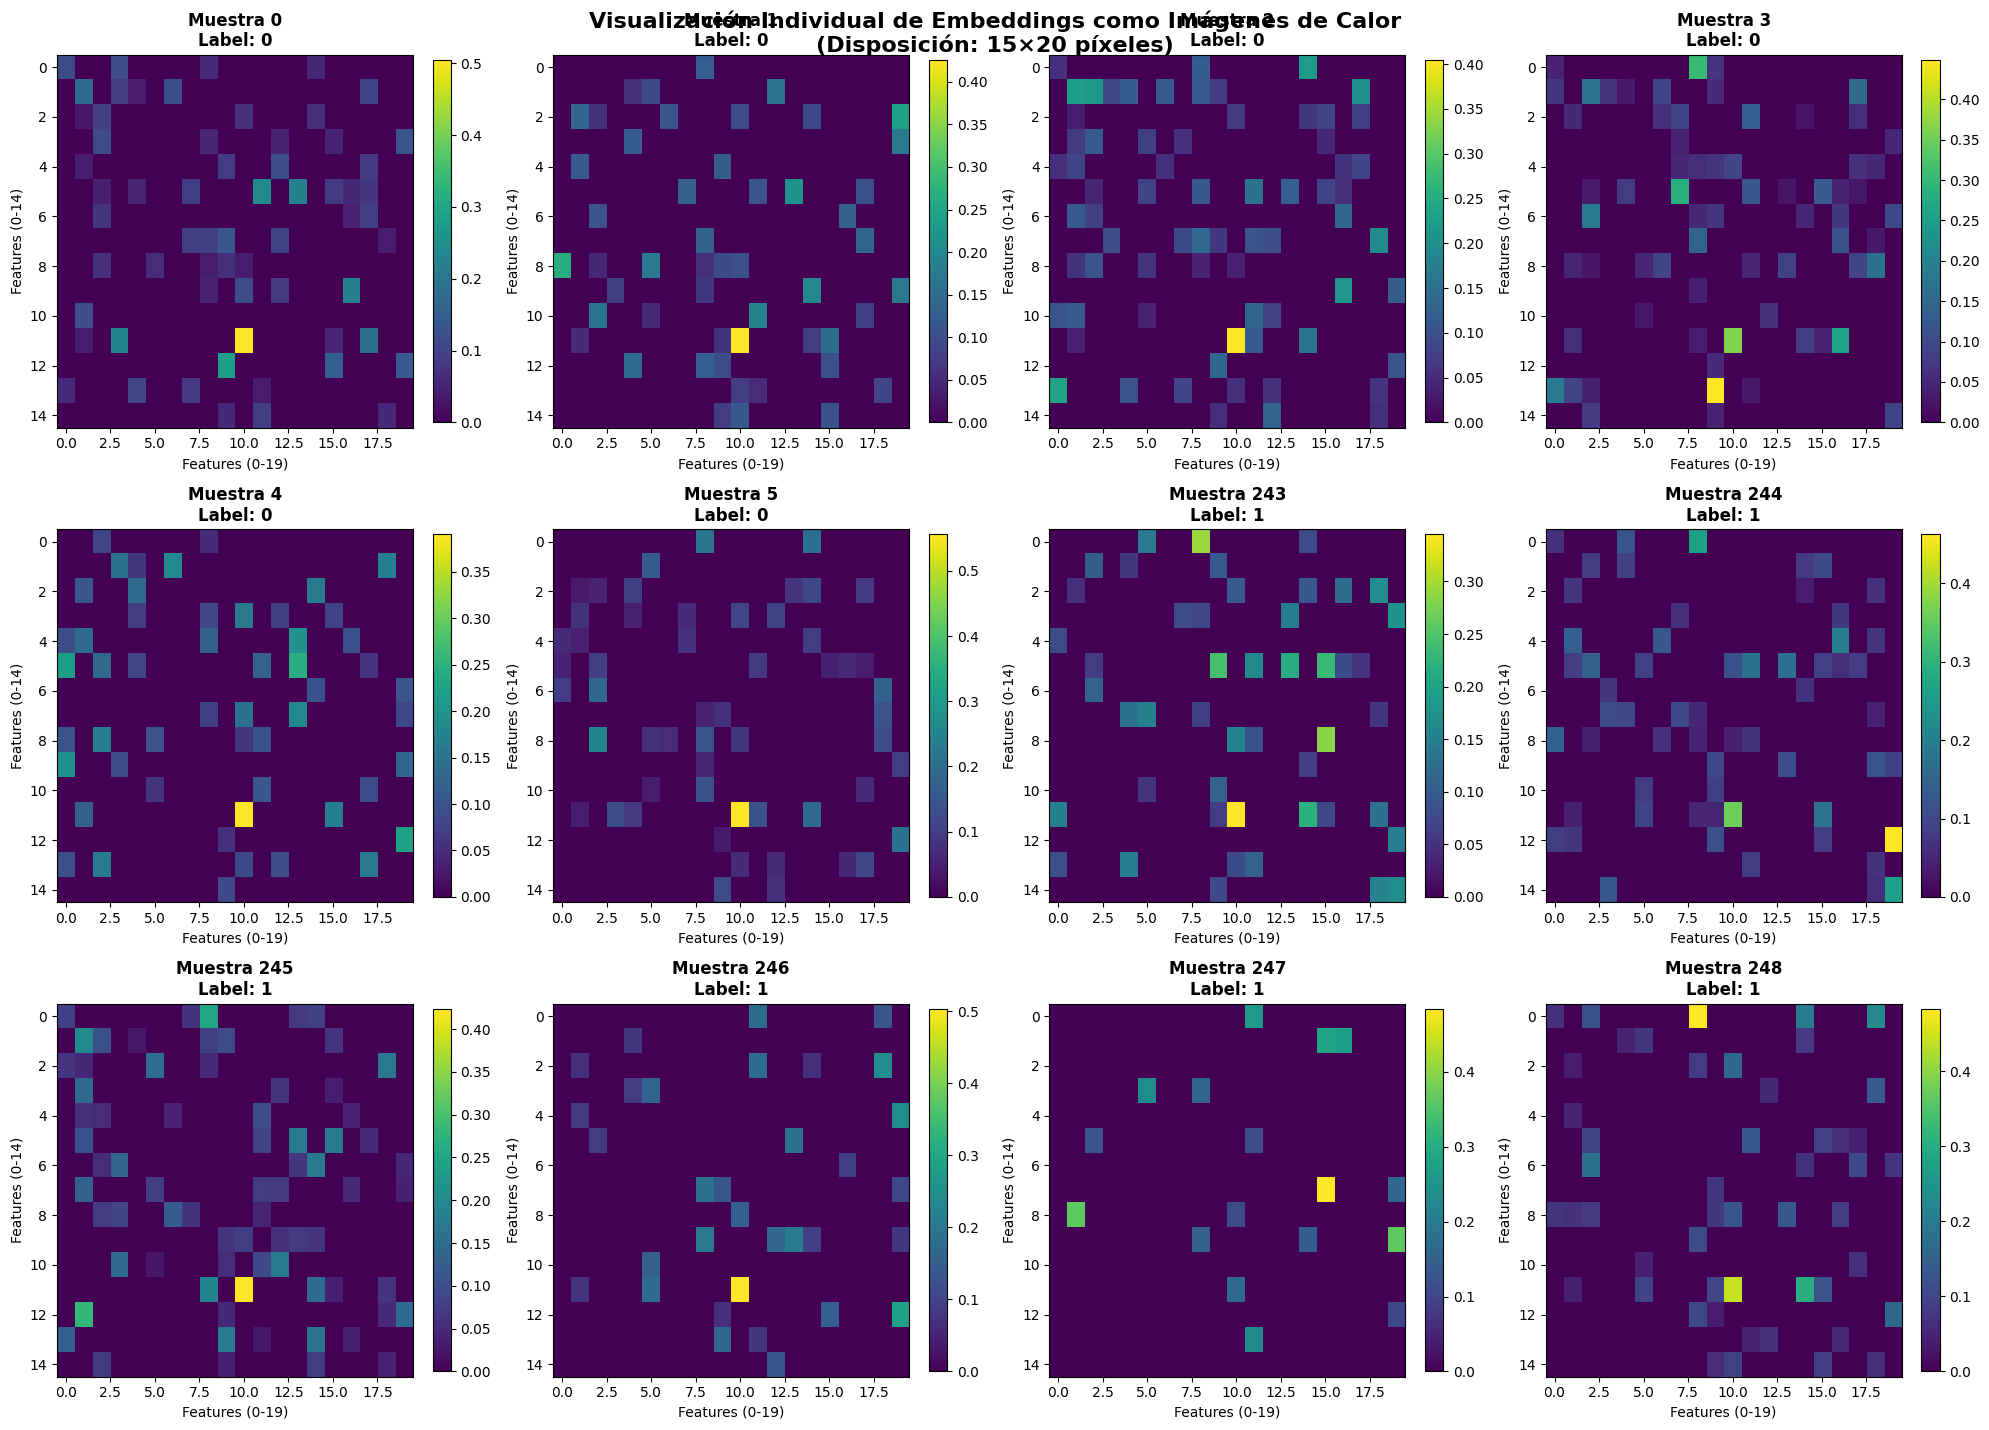

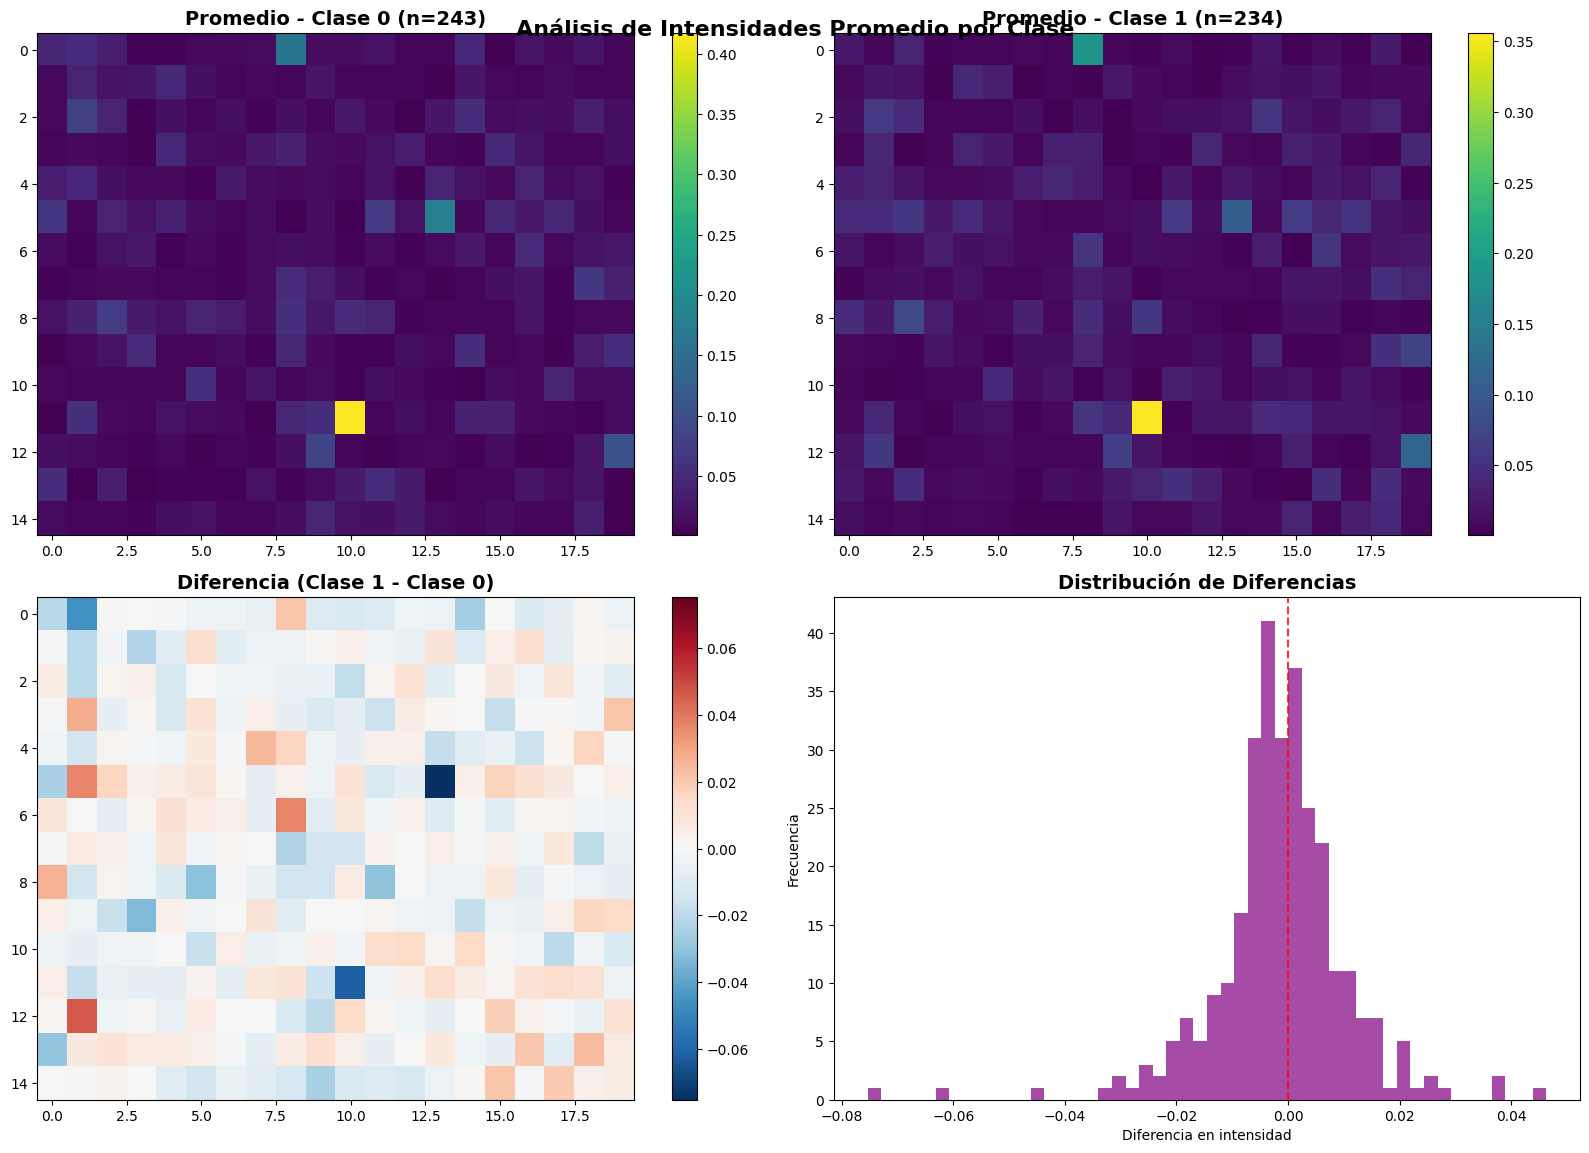


📈 Estadísticas de diferencias entre clases:
   Máxima diferencia: 0.0462
   Mínima diferencia: -0.0753
   Diferencia promedio: -0.0015
   Features con mayor diferencia: (5, 13)


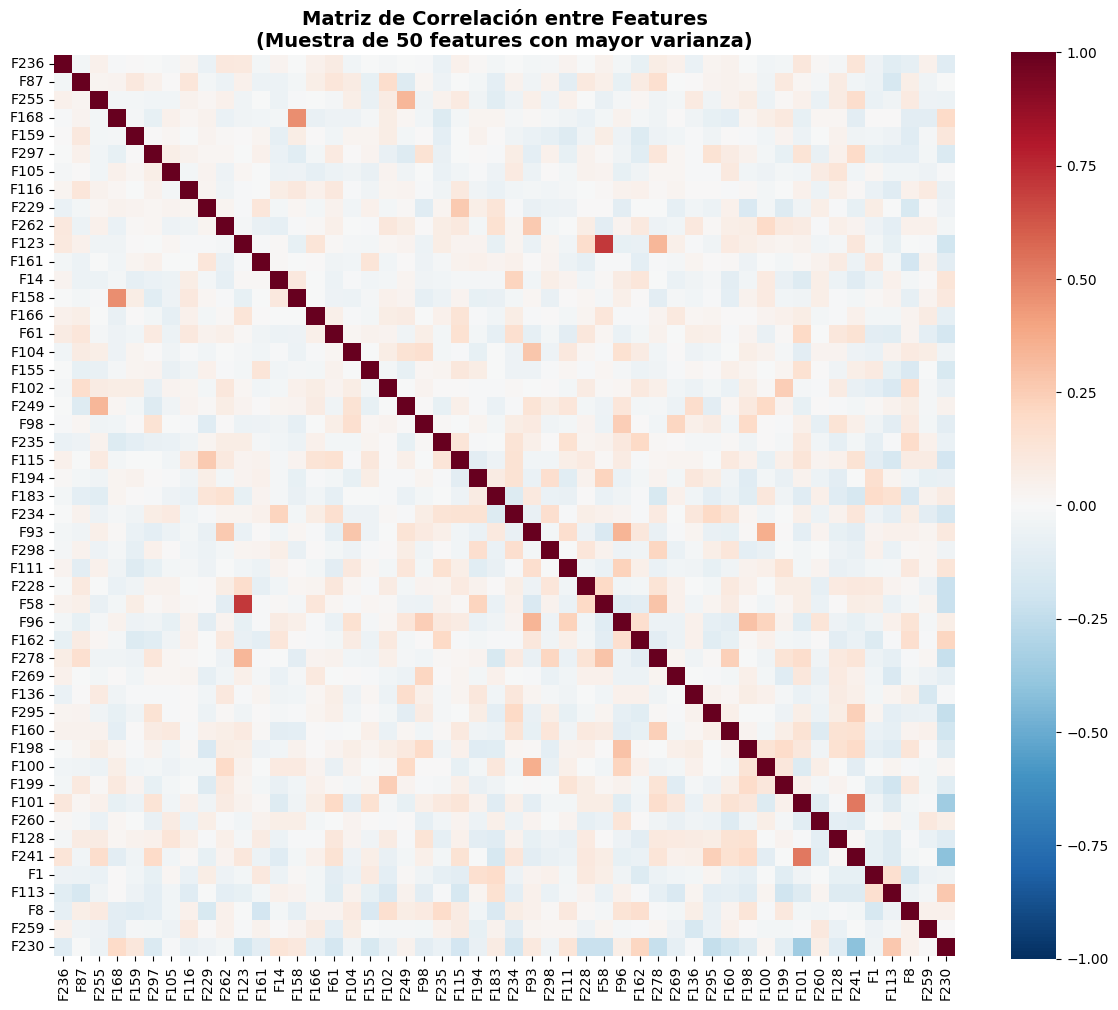

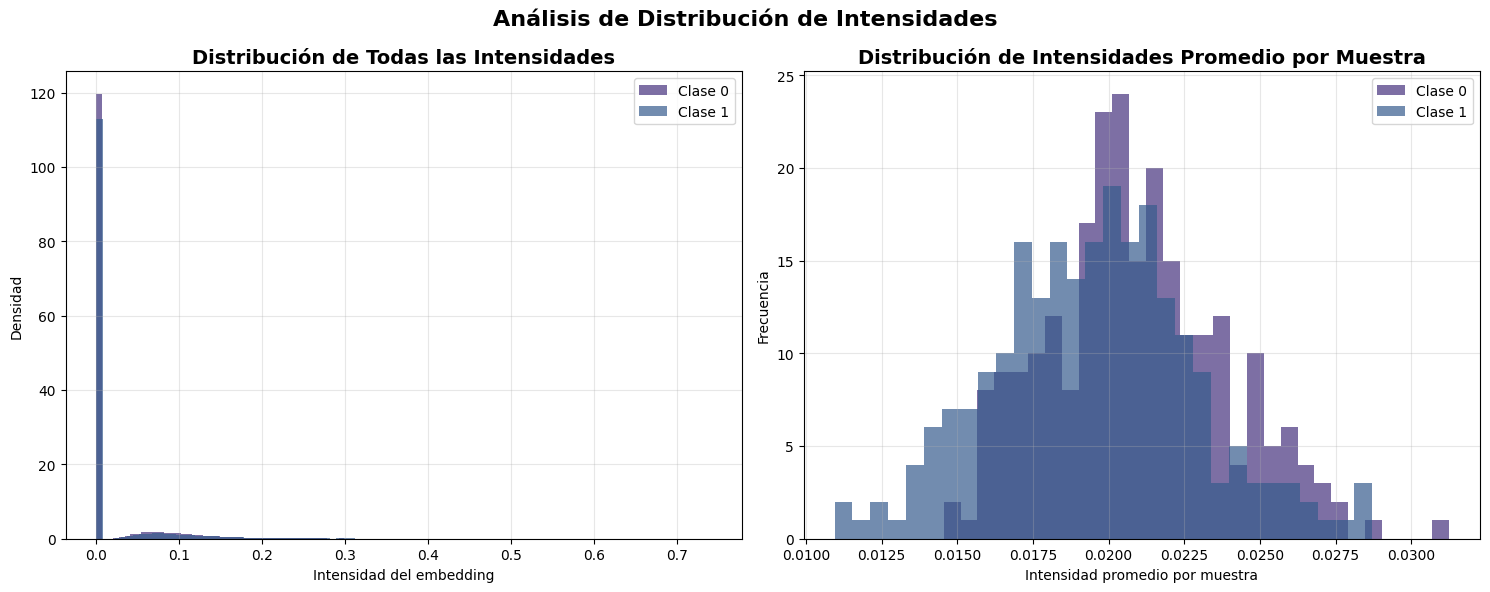


📊 Estadísticas de intensidades:
   Clase 0 - Media: 0.0209, Std: 0.0029
   Clase 1 - Media: 0.0195, Std: 0.0034


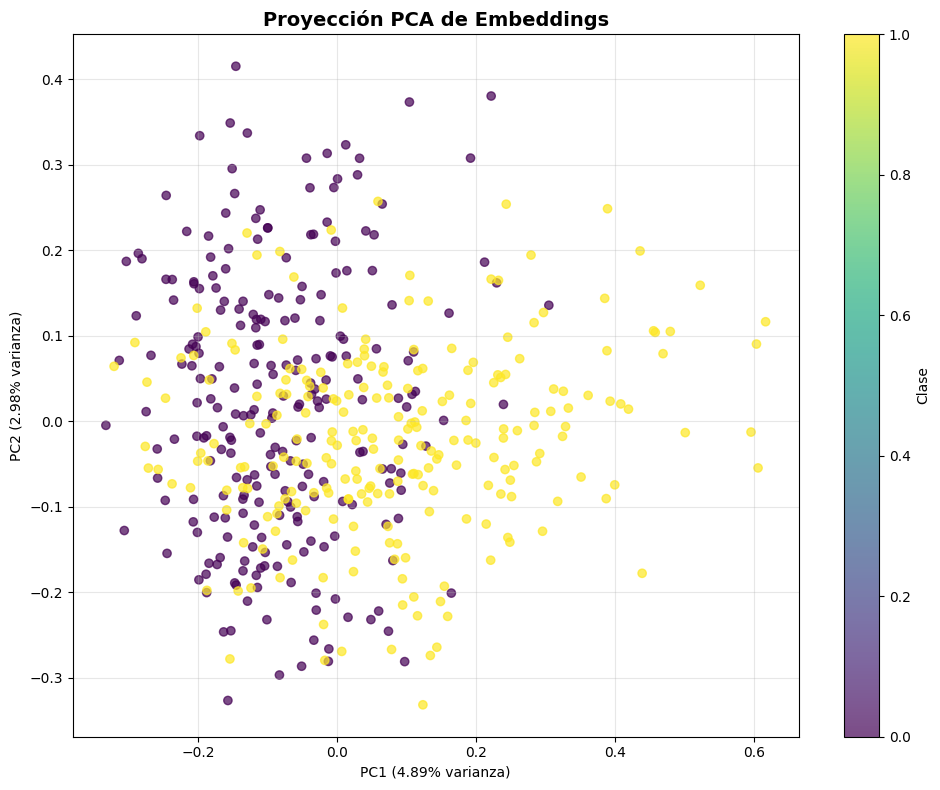

📉 Varianza explicada por PCA:
   PC1: 4.887%
   PC2: 2.979%
   Total: 7.866%

✅ Visualizaciones completadas!


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Configuración de estilos
plt.style.use('default')
sns.set_palette("viridis")

print("📊 Generando visualizaciones de intensidad de píxeles...")

# =============================================================================
# 1. PREPARAR LOS DATOS
# =============================================================================

# Separar características de embedding
feature_cols = [f for f in X.columns if f.startswith('feature_')]
X_embeddings = X[feature_cols].values

print(f"Forma de los embeddings: {X_embeddings.shape}")
print(f"Rango de valores: [{X_embeddings.min():.3f}, {X_embeddings.max():.3f}]")

# =============================================================================
# 2. VISUALIZACIÓN DE EMBEDDINGS COMO IMÁGENES INDIVIDUALES
# =============================================================================

# Configurar la visualización - reorganizar los 300 features en una matriz 2D
# Podemos probar diferentes disposiciones: 15x20, 12x25, 10x30, etc.
rows, cols = 15, 20  # 15*20 = 300

def plot_individual_embeddings(X_data, y_data, n_samples=12, rows=15, cols=20):
    """Plot individual embeddings como imágenes de calor"""
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.ravel()
    
    # Seleccionar muestras balanceadas (si es posible)
    class_0_indices = np.where(y_data == 0)[0]
    class_1_indices = np.where(y_data == 1)[0]
    
    # Tomar muestras iguales de cada clase
    n_each = n_samples // 2
    indices = (list(class_0_indices[:n_each]) + 
               list(class_1_indices[:n_each]))
    
    for i, idx in enumerate(indices[:n_samples]):
        if idx < len(X_data):
            # Reformatear a 2D
            embedding_2d = X_data[idx].reshape(rows, cols)
            
            # Plot
            im = axes[i].imshow(embedding_2d, cmap='viridis', aspect='auto',
                               interpolation='nearest')
            axes[i].set_title(f'Muestra {idx}\nLabel: {y_data[idx]}', 
                            fontsize=12, fontweight='bold')
            axes[i].set_xlabel(f'Features (0-{cols-1})')
            axes[i].set_ylabel(f'Features (0-{rows-1})')
            
            # Añadir barra de color
            plt.colorbar(im, ax=axes[i], fraction=0.046)
    
    # Ocultar ejes vacíos
    for j in range(len(indices), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Visualización Individual de Embeddings como Imágenes de Calor\n'
                f'(Disposición: {rows}×{cols} píxeles)', 
                fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()

# Llamar la función
plot_individual_embeddings(X_embeddings, y, n_samples=12, rows=rows, cols=cols)

# =============================================================================
# 3. MAPA DE CALOR PROMEDIO POR CLASE
# =============================================================================

def plot_class_average_heatmaps(X_data, y_data, rows=15, cols=20):
    """Plot promedios de embeddings por clase"""
    # Calcular promedios por clase
    class_0_mask = (y_data == 0)
    class_1_mask = (y_data == 1)
    
    if np.any(class_0_mask) and np.any(class_1_mask):
        avg_class_0 = X_data[class_0_mask].mean(axis=0).reshape(rows, cols)
        avg_class_1 = X_data[class_1_mask].mean(axis=0).reshape(rows, cols)
        diff = avg_class_1 - avg_class_0  # Diferencia entre clases
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Clase 0
        im0 = axes[0,0].imshow(avg_class_0, cmap='viridis', aspect='auto')
        axes[0,0].set_title(f'Promedio - Clase 0 (n={np.sum(class_0_mask)})', 
                           fontsize=14, fontweight='bold')
        plt.colorbar(im0, ax=axes[0,0])
        
        # Clase 1
        im1 = axes[0,1].imshow(avg_class_1, cmap='viridis', aspect='auto')
        axes[0,1].set_title(f'Promedio - Clase 1 (n={np.sum(class_1_mask)})', 
                           fontsize=14, fontweight='bold')
        plt.colorbar(im1, ax=axes[0,1])
        
        # Diferencia
        im_diff = axes[1,0].imshow(diff, cmap='RdBu_r', aspect='auto', 
                                  vmin=-np.abs(diff).max(), 
                                  vmax=np.abs(diff).max())
        axes[1,0].set_title('Diferencia (Clase 1 - Clase 0)', 
                           fontsize=14, fontweight='bold')
        plt.colorbar(im_diff, ax=axes[1,0])
        
        # Distribución de diferencias
        axes[1,1].hist(diff.flatten(), bins=50, alpha=0.7, color='purple')
        axes[1,1].axvline(x=0, color='red', linestyle='--', alpha=0.8)
        axes[1,1].set_title('Distribución de Diferencias', 
                           fontsize=14, fontweight='bold')
        axes[1,1].set_xlabel('Diferencia en intensidad')
        axes[1,1].set_ylabel('Frecuencia')
        
        plt.suptitle('Análisis de Intensidades Promedio por Clase', 
                    fontsize=16, fontweight='bold', y=0.95)
        plt.tight_layout()
        plt.show()
        
        # Estadísticas de diferencia
        print(f"\n📈 Estadísticas de diferencias entre clases:")
        print(f"   Máxima diferencia: {diff.max():.4f}")
        print(f"   Mínima diferencia: {diff.min():.4f}")
        print(f"   Diferencia promedio: {diff.mean():.4f}")
        print(f"   Features con mayor diferencia: {np.unravel_index(np.argmax(np.abs(diff)), diff.shape)}")

plot_class_average_heatmaps(X_embeddings, y, rows=rows, cols=cols)

# =============================================================================
# 4. MATRIZ DE CORRELACIÓN ENTRE FEATURES
# =============================================================================

def plot_feature_correlation(X_data, max_features=50):
    """Plot matriz de correlación entre features (muestra reducida)"""
    # Tomar una muestra de features para no saturar la visualización
    if X_data.shape[1] > max_features:
        # Seleccionar features con mayor varianza
        variances = np.var(X_data, axis=0)
        selected_indices = np.argsort(variances)[-max_features:]
        X_sample = X_data[:, selected_indices]
        feature_labels = [f'F{idx}' for idx in selected_indices]
    else:
        X_sample = X_data
        feature_labels = [f'F{i}' for i in range(X_data.shape[1])]
    
    # Calcular matriz de correlación
    corr_matrix = np.corrcoef(X_sample.T)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, 
                xticklabels=feature_labels, 
                yticklabels=feature_labels,
                cmap='RdBu_r', 
                center=0,
                vmin=-1, vmax=1,
                square=True)
    plt.title(f'Matriz de Correlación entre Features\n(Muestra de {max_features} features con mayor varianza)', 
             fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_feature_correlation(X_embeddings)

# =============================================================================
# 5. DISTRIBUCIÓN DE INTENSIDADES
# =============================================================================

def plot_intensity_distributions(X_data, y_data):
    """Plot distribuciones de intensidades por clase"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Todas las intensidades
    axes[0].hist(X_data[y_data == 0].flatten(), 
                bins=100, alpha=0.7, label='Clase 0', density=True)
    axes[0].hist(X_data[y_data == 1].flatten(), 
                bins=100, alpha=0.7, label='Clase 1', density=True)
    axes[0].set_title('Distribución de Todas las Intensidades', 
                     fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Intensidad del embedding')
    axes[0].set_ylabel('Densidad')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Intensidades promedio por muestra
    mean_intensities_0 = X_data[y_data == 0].mean(axis=1)
    mean_intensities_1 = X_data[y_data == 1].mean(axis=1)
    
    axes[1].hist(mean_intensities_0, bins=30, alpha=0.7, label='Clase 0')
    axes[1].hist(mean_intensities_1, bins=30, alpha=0.7, label='Clase 1')
    axes[1].set_title('Distribución de Intensidades Promedio por Muestra', 
                     fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Intensidad promedio por muestra')
    axes[1].set_ylabel('Frecuencia')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('Análisis de Distribución de Intensidades', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Estadísticas
    print(f"\n📊 Estadísticas de intensidades:")
    print(f"   Clase 0 - Media: {mean_intensities_0.mean():.4f}, Std: {mean_intensities_0.std():.4f}")
    print(f"   Clase 1 - Media: {mean_intensities_1.mean():.4f}, Std: {mean_intensities_1.std():.4f}")

plot_intensity_distributions(X_embeddings, y)

# =============================================================================
# 6. VISUALIZACIÓN CON PCA (OPCIONAL)
# =============================================================================

from sklearn.decomposition import PCA

def plot_pca_projection(X_data, y_data):
    """Plot proyección PCA de los embeddings"""
    # Aplicar PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_data)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                         c=y_data, cmap='viridis', alpha=0.7)
    plt.colorbar(scatter, label='Clase')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
    plt.title('Proyección PCA de Embeddings', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"📉 Varianza explicada por PCA:")
    print(f"   PC1: {pca.explained_variance_ratio_[0]:.3%}")
    print(f"   PC2: {pca.explained_variance_ratio_[1]:.3%}")
    print(f"   Total: {pca.explained_variance_ratio_.sum():.3%}")

plot_pca_projection(X_embeddings, y)

print("\n✅ Visualizaciones completadas!")

In [55]:
df

,age,sex,label,clean_transcripts,sex_encoded
0,58.0,female,Control,the scene is in the in the kitchen . the mothe...,0
1,59.0,female,Control,oh I see the sink is running over . I see the ...,0
2,60.0,female,Control,um a boy and a girl are in the kitchen with th...,0
3,61.0,female,Control,okay . it was summertime and mother and the ch...,0
4,72.0,male,Control,clearsthroat wait until I put my glasses on . ...,1
...,...,...,...,...,...
543,83.0,male,ProbableAD,"yeah . everythings thats . , not according to ...",1
544,78.0,female,ProbableAD,"well , theres a cookie jar there with the lid ...",0
545,65.0,female,ProbableAD,you want me to tell you okay uh the boys getti...,0
546,73.0,female,ProbableAD,"uh well , heres the child reaching up but hes ...",0


## ANALISIS SINTACTICO

In [62]:
import pandas as pd
import re
from collections import Counter

# Cargar df
df = pd.read_csv(r"C:\Users\lclai\Desktop\transcripts_cleaned.csv")

# Codificar sexo si no está codificado
if 'sex_encoded' not in df.columns:
    from sklearn.preprocessing import LabelEncoder
    le_sex = LabelEncoder()
    df['sex_encoded'] = le_sex.fit_transform(df['sex'])

# Separar grupos
control_df = df[df['label'] == 'Control']
ad_df = df[df['label'] == 'ProbableAD']

def extract_text_features_simple(text):
    # Minusculas
    text_lower = text.lower()
    
    # Palabras (solo a-z)
    words = re.findall(r'\b[a-z]+\b', text_lower)
    unique_words = set(words)
    num_words = len(words)
    num_unique = len(unique_words)
    avg_word_len = sum(len(w) for w in words)/num_words if num_words > 0 else 0

    # Oraciones por puntos
    sents = [s.strip() for s in text.split('.') if s.strip()]
    num_sents = len(sents)
    avg_sent_len = num_words/num_sents if num_sents > 0 else 0

    # Palabras más repetidas
    word_counts = Counter(words)
    most_common = word_counts.most_common(5)

    # Nombres propios simples: palabras con mayúscula inicial en el texto original
    proper_nouns = re.findall(r'\b[A-Z][a-z]*\b', text)
    num_proper_nouns = len(proper_nouns)

    return pd.Series({
        'num_words': num_words,
        'num_unique_words': num_unique,
        'avg_word_len': avg_word_len,
        'num_sentences': num_sents,
        'avg_sent_len': avg_sent_len,
        'top_words': most_common,
        'num_proper_nouns': num_proper_nouns
    })

# Aplicar a cada grupo
control_features = control_df['clean_transcripts'].apply(extract_text_features_simple)
ad_features = ad_df['clean_transcripts'].apply(extract_text_features_simple)

# Promedios por grupo
print("=== Control ===")
print(control_features.mean(numeric_only=True))

print("\n=== ProbableAD ===")
print(ad_features.mean(numeric_only=True))

# Top palabras por grupo
def aggregate_top_words(feature_series):
    all_counts = Counter()
    for x in feature_series:
        all_counts.update(dict(x))
    return all_counts.most_common(10)

print("\nTop palabras Control:")
print(aggregate_top_words(control_features['top_words']))

print("\nTop palabras ProbableAD:")
print(aggregate_top_words(ad_features['top_words']))


=== Control ===
num_words           110.888889
num_unique_words     65.806584
avg_word_len          3.980380
num_sentences        13.049383
avg_sent_len          8.622588
num_proper_nouns      1.748971
dtype: float64

=== ProbableAD ===
num_words           104.645299
num_unique_words     60.059829
avg_word_len          3.852836
num_sentences        13.128205
avg_sent_len          7.961336
num_proper_nouns      2.264957
dtype: float64

Top palabras Control:
[('the', 2942), ('and', 1004), ('is', 993), ('a', 596), ('uh', 359), ('to', 186), ('on', 141), ('i', 139), ('cookie', 105), ('in', 83)]

Top palabras ProbableAD:
[('the', 2327), ('and', 1049), ('uh', 460), ('is', 389), ('a', 369), ('i', 263), ('on', 176), ('shes', 111), ('to', 80), ('that', 71)]
